In [29]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from langgraph.checkpoint.memory import MemorySaver

In [15]:
load_dotenv()

True

In [16]:
llm = ChatGroq(
    model=os.getenv("LLM_MODEL"),
    temperature=0.7,
    api_key=os.getenv("LLM_API_KEY")
)

In [17]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
def chat_node(state: ChatState):
    # take user query from state
    messages = state["messages"]

    # send to llm
    response = llm.invoke(messages)

    # response store to state
    return {"messages" : [response]}    


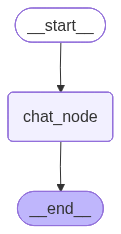

In [30]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [20]:
initial_state = {
    "messages" : [HumanMessage(content="What is the capital of India")]
}

workflow.invoke(initial_state)["messages"][-1].content

'The capital of India is New Delhi.'

In [28]:
while True:
    user_message = input("You: ").strip()

    if user_message.lower() in ["exit", "bye", "quit"]:
        print("Goodbye!")
        break

    # Print user message
    print(f"\nYou: {user_message}")

    response = workflow.invoke({"messages" : [HumanMessage(content=user_message)]})

    print(f'AI: {response["messages"][-1].content}')


You: hi
AI: It's nice to meet you. Is there something I can help you with or would you like to chat?

You: add 5 + 5
AI: 5 + 5 = 10.

You: add result + 10
AI: There is no result to add 10 to. This conversation just started. If you provide a number or a result, I can help you add 10 to it.
Goodbye!


In [31]:
thread_id = "1"

while True:
    user_message = input("You: ").strip()

    if user_message.lower() in ["exit", "bye", "quit"]:
        print("Goodbye!")
        break

    # Print user message
    print(f"\nYou: {user_message}")

    config = {"configurable" : {"thread_id" : thread_id}}

    response = workflow.invoke({"messages" : [HumanMessage(content=user_message)]}, config=config)

    print(f'AI: {response["messages"][-1].content}')


You: hi bro
AI: What's up? How can I help you today?

You: my name is Bhushan
AI: Nice to meet you, Bhushan. How's your day going so far? Is there something I can help you with or would you like to chat?

You: what is my name
AI: Your name is Bhushan.

You: add 10 + 2
AI: 10 + 2 = 12

You: multiply result to 2
AI: We had 12 as the result of the previous calculation. 

12 * 2 = 24
Goodbye!


In [34]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi bro', additional_kwargs={}, response_metadata={}, id='54ba7ef5-db9e-4dd2-8d2f-8b2d03e34e6a'), AIMessage(content="What's up? How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 37, 'total_tokens': 49, 'completion_time': 0.027578461, 'completion_tokens_details': None, 'prompt_time': 0.005681314, 'prompt_tokens_details': None, 'queue_time': 0.372856188, 'total_time': 0.033259775}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e741f-6f37-7120-bfb4-645a48a5a549-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 12, 'total_tokens': 49}), HumanMessage(content='my name is Bhushan', additional_kwargs={}, response_metadata={}, id='88b622d0-234e-4034-8c8d-e8ecf56644ca'), AIMe

In [38]:
import json

# Get workflow state
workflow_state = workflow.get_state(config=config)

# Display state as formatted JSON
print("=" * 70)
print("Workflow State (JSON):")
print("=" * 70)
print(json.dumps(workflow_state, indent=2, default=str))

Workflow State (JSON):
[
  {
    "messages": [
      "content='hi bro' additional_kwargs={} response_metadata={} id='54ba7ef5-db9e-4dd2-8d2f-8b2d03e34e6a'",
      "content=\"What's up? How can I help you today?\" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 37, 'total_tokens': 49, 'completion_time': 0.027578461, 'completion_tokens_details': None, 'prompt_time': 0.005681314, 'prompt_tokens_details': None, 'queue_time': 0.372856188, 'total_time': 0.033259775}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e741f-6f37-7120-bfb4-645a48a5a549-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 37, 'output_tokens': 12, 'total_tokens': 49}",
      "content='my name is Bhushan' additional_kwargs={} response_metadata={} id='88b622d0-234e-4034-8c8d-e8ecf56644ca'",
      "content=\"